# 05 - Strategy-4 q(f) schedule

With `ncdm_quadrature_strategy = 4` and no explicit bin count, `input.c` picks the daughter's number of
momentum bins from f_acc: 250 below f = 0.1, 1000 up to 0.3, 2000 above (spec
`2026-07-02-adaptive-daughter-q-schedule-design.md`; override with `accdm_q_schedule_f_edges` and
`accdm_q_schedule_q_sizes`). This compares each regime with a 3001-bin reference.

The target is max |ΔP/P| and max |ΔC_ℓ/C_ℓ| (lensed TT, EE, φφ) ≤ 10⁻³, with P(k) also reported in the
EFT window k = 0.1–0.3 h/Mpc. The notebook reports, it does not assert: if a regime misses the target,
raise its bin count and copy the table into `input.c`. Strategy 5 (notebook 06 onwards) is the
production grid; this schedule only matters for strategy-4 runs.

**Result** (m = 10¹⁶ GeV). No regime meets 10⁻³. The 250-bin regime (f < 0.1) is off by 5·10⁻³ in P(k)
and 6·10⁻³ in TT; 1000 and 2000 bins come close (P(k) 3–7·10⁻⁴, TT and EE ≤ 1.7·10⁻³, φφ 1.4–2.4·10⁻³)
at 1.4–20× the speed of the reference. Strategy 5 does better with 71 bins (notebook 06), so use it;
for strategy-4 runs that need 10⁻³, raise the f < 0.1 regime.

Model: κ = 12.1, a_t = 0.133, η = 10¹¹ GeV/m. The 3001-bin references take 10–20 minutes each;
`FAST` runs one mass.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from accdm_nb import accdm_params, run_class, show, plot_style

plot_style()

FAST = True
TOL = 1e-3
LMAX = 2500
K_NODES = np.logspace(-3, 0, 60)                 # 1/Mpc
EFT = (K_NODES >= 0.1*0.6732) & (K_NODES <= 0.3*0.6732)
REFERENCE_BINS = 3001
MASSES = [1e16] if FAST else [1e12, 1e16]
F_POINTS = [0.01, 0.15, 0.5]                      # one per regime
OUTPUT = {'output': 'tCl,pCl,lCl,mPk', 'lensing': 'yes', 'l_max_scalars': LMAX,
          'P_k_max_1/Mpc': 1.0, 'z_max_pk': 0.0, 'reionization_z_start_max': 80,
          'ncdm_quadrature_strategy': '0, 4'}


def scheduled_bins(f_acc):
    return 250 if f_acc < 0.1 else 1000 if f_acc < 0.3 else 2000


def spectra(cosmo):
    cl = cosmo.lensed_cl(LMAX)
    return {**{s: np.asarray(cl[s])[2:] for s in ('tt', 'ee', 'pp')},
            'pk': np.array([cosmo.pk(k, 0.0) for k in K_NODES])}


def max_rel(a, b):
    return float(np.max(np.abs(a/b - 1)))

In [2]:
rows = []
for mass in MASSES:
    for f in F_POINTS:
        sched = run_class(accdm_params(f, mass, **OUTPUT), spectra)
        ref = run_class(accdm_params(f, mass, ncdm_N_momentum_bins='15, {}'.format(REFERENCE_BINS), **OUTPUT), spectra)
        assert 'error' not in sched and 'error' not in ref, (sched.get('error'), ref.get('error'))
        rows.append({'mass': mass, 'f_acc': f, 'bins': scheduled_bins(f),
                     'P(k)': max_rel(sched['pk'], ref['pk']), 'P(k) EFT': max_rel(sched['pk'][EFT], ref['pk'][EFT]),
                     'TT': max_rel(sched['tt'], ref['tt']), 'EE': max_rel(sched['ee'], ref['ee']),
                     'φφ': max_rel(sched['pp'], ref['pp']),
                     'time [s]': sched['sec'], 'speed-up': ref['sec']/sched['sec']})
table = pd.DataFrame(rows).set_index(['mass', 'f_acc'])
table['meets 1e-3'] = (table[['P(k)', 'TT', 'EE', 'φφ']] <= TOL).all(axis=1)
show(table, {'mass': '{:.0e}', 'bins': '{:d}', 'time [s]': '{:.0f}', 'speed-up': '{:.1f}'}, default='{:.1e}')

bins     P(k) P(k) EFT       TT       EE       φφ  \
mass         f_acc                                                      
1.000000e+16 0.01    250  4.9e-03  1.8e-03  6.1e-03  5.7e-03  2.4e-03   
             0.15   1000  3.3e-04  2.2e-04  7.4e-04  1.3e-03  2.4e-03   
             0.50   2000  7.3e-04  4.8e-04  1.6e-03  1.7e-03  1.4e-03   

                   time [s] speed-up meets 1e-3  
mass         f_acc                               
1.000000e+16 0.01        59     20.2      False  
             0.15       263      4.3      False  
             0.50       547      1.4      False

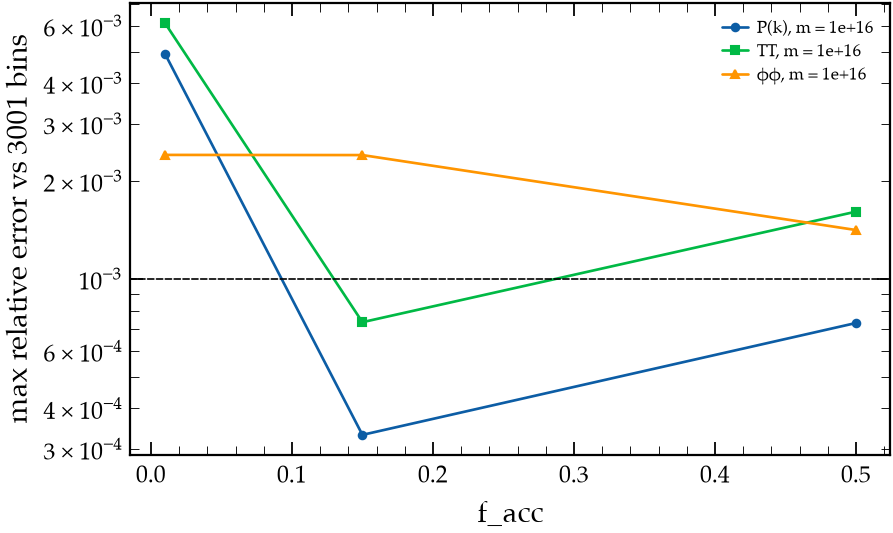

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.6), constrained_layout=True)
for col, marker in (('P(k)', 'o'), ('TT', 's'), ('φφ', '^')):
    for mass in MASSES:
        sub = table.xs(mass, level='mass')
        ax.semilogy(sub.index, sub[col], marker + '-', label='{}, m = {:.0e}'.format(col, mass))
ax.axhline(TOL, color='k', ls='--', lw=0.8)
ax.set_xlabel('f_acc')
ax.set_ylabel('max relative error vs {} bins'.format(REFERENCE_BINS))
ax.legend(fontsize=8)
plt.show()